# 13. seasonal·time fold 랩 (F0~F4)

> 선행 노트북: [12_local_public_calibration_lab.ipynb](12_local_public_calibration_lab.ipynb)
> 선행 설계서: [02-data-modeling-spec.md](../docs/design/02-data-modeling-spec.md) 6절,
> [04-final-solution-blueprint.md](../docs/design/04-final-solution-blueprint.md) 6절,
> [06-preprocessing-guardrails.md](../docs/design/06-preprocessing-guardrails.md) 5.2·5.4절

노트북 12는 Public 두 점으로 기울기를 재려다 **문턱**을 얻고 끝났다.
40% 표본이 만드는 paired 잡음이 0.00211이고, 후보 간 간격이 그보다 작으면 순위를
확정하지 않기로 했다(Decision Box ⑱). 그런데 그 문턱은 **2024 단일 holdout 하나**에서
잰 값이다. 2024라는 특정 해에 좌우된 값이면 문턱 자체가 틀린다.

**연구 질문**

> 프리셋 4종의 순위는 2024 단일 holdout 밖에서도 유지되는가?
> 그리고 fold를 바꿨을 때 개선분은 얼마나 흔들리는가?

**두 질문을 분리하는 것이 이 노트북의 핵심이다.** "누가 더 나은가"(순위)와
"얼마나 더 나은가"(크기)는 다른 질문이고, 답도 다르게 나온다.

Bergmeir와 Benítez가 정리했듯 시계열 예측 평가에서 fold가 하나뿐이면 그 해의
기상 조건에 결과가 좌우된다. 설계서 06 5.2절이 이 노트북을 예고한 이유다.

In [1]:
from pathlib import Path
import hashlib
import re
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import font_manager


def resolveProjectRoot():
  """worktree/일반 체크아웃 어디서 실행하든 src를 찾는다."""
  here = Path.cwd().resolve()
  for candidate in [here, *here.parents]:
    if (candidate / "src" / "baram").is_dir():
      return candidate
  raise RuntimeError("src/baram을 찾지 못했습니다")


def resolveOfficialDataDir(projectRoot):
  for candidate in [projectRoot, *projectRoot.parents]:
    dataDir = candidate / "data" / "raw" / "open"
    if (dataDir / "train" / "train_labels.csv").is_file():
      return dataDir
  raise RuntimeError("공식 데이터 디렉터리를 찾지 못했습니다")


projectRoot = resolveProjectRoot()
if str(projectRoot / "src") not in sys.path:
  sys.path.insert(0, str(projectRoot / "src"))
dataDir = resolveOfficialDataDir(projectRoot)

sns.set_theme(style="whitegrid")
fontCandidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"]
availableFonts = {font.name for font in font_manager.fontManager.ttflist}
selectedFont = next((font for font in fontCandidates if font in availableFonts), "DejaVu Sans")
plt.rcParams["font.family"] = selectedFont
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")

print(f"project root : {projectRoot.name}")
print(f"official data: {dataDir}")
print(f"한글 폰트    : {selectedFont}")

project root : baram-submission-ledger-slope-d665d7
official data: C:\Users\kik32\workspace\Dacon\baram-2026-wind-power-forecasting\data\raw\open
한글 폰트    : Malgun Gothic


09~12와 같은 탐색 규약이다. 이 노트북은 `outputs/`에 아무것도 쓰지 않으므로
artifact 경로 탐색은 없다.

---

## 1. fold 정의 — 설계서 두 곳이 충돌한다

F1~F4는 설계서 두 곳에 적혀 있는데 **정의가 서로 다르다.**

| 출처 | F1 train | F1 valid |
|------|----------|----------|
| 설계서 02 6.2절 (데이터 공개 **전**) | 2022-2023 | 2024 겨울/봄 |
| 설계서 04 6절 (공개 **후** 최종 blueprint) | 2022-2023 **+ 2024 일부 제외** | 2024년 1-5월 |

문서 지위는 04가 위다. 그런데 04의 F1은 valid가 2024년 1-5월인데 train에 2024의
나머지가 들어간다. 이는 **같은 문서 바로 윗줄**의 규칙을 위반한다.

> random split은 금지한다. **모든 validation은 시간 순서를 지킨다.** (설계서 04 6절)

2024년 6-12월로 학습해 2024년 1-5월을 맞히는 것은 미래로 과거를 예측하는 것이다.
한편 설계서 02는 424행에 명시적 지시를 남겨 두었다.

> 공식 데이터 공개 후 실제 label 범위가 다르면 이 표를 재계산한다.

데이터가 공개됐고 아래에서 확인하듯 Group 3 라벨 범위가 실제로 달랐으므로,
재계산 조건이 충족된다.

In [2]:
def readOfficial(relativePath):
  return pd.read_csv(dataDir / relativePath, encoding="utf-8-sig")


from baram.metrics import CAPACITY_KWH, TARGET_COLS, metric

trainLabels = readOfficial("train/train_labels.csv")
trainLabels["kst_dtm"] = pd.to_datetime(trainLabels["kst_dtm"])

coverageRows = []
for column in TARGET_COLS:
  labelled = trainLabels.loc[trainLabels[column].notna(), "kst_dtm"]
  coverageRows.append(
    {
      "group": column,
      "라벨 행 수": len(labelled),
      "첫 라벨": labelled.min(),
      "마지막 라벨": labelled.max(),
      "2022 라벨": int((labelled.dt.year == 2022).sum()),
    }
  )
coverageFrame = pd.DataFrame(coverageRows).set_index("group")

print(f"라벨 전체 범위 : {trainLabels['kst_dtm'].min()} ~ {trainLabels['kst_dtm'].max()}  ({len(trainLabels)}행)")
display(coverageFrame)
print("Group 3은 2022년 라벨이 0행이다 — fold의 train 창이 2022뿐이면 Group 3을 학습할 수 없다.")

라벨 전체 범위 : 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00  (26304행)


,라벨 행 수,첫 라벨,마지막 라벨,2022 라벨
group,,,,
kpx_group_1,26200,2022-01-01 01:00:00,2025-01-01,8664
kpx_group_2,26201,2022-01-01 01:00:00,2025-01-01,8664
kpx_group_3,17538,2023-01-01 01:00:00,2025-01-01,0


Group 3은 2022년 라벨이 0행이다 — fold의 train 창이 2022뿐이면 Group 3을 학습할 수 없다.


### 1-1. 재계산 조건이 실제로 충족된다

Group 3 라벨은 **2023-01-01 01:00부터** 시작하며 2022년 라벨이 하나도 없다.
설계서 02가 예고한 "실제 label 범위가 다르면 재계산한다"에 해당한다.

### Decision Box ⑲ — fold의 *목적*은 설계서 04를 따르고 *구간*은 시간 순서로 재계산한다

**선택지**

- (A) 설계서 04를 문자 그대로 구현한다 (F1/F2 train에 2024 일부 포함)
- (B) 설계서 02의 구간을 쓴다
- (C) 04의 fold별 목적을 유지하되 구간만 시간 순서를 지키도록 재계산한다

**근거**

(A)는 04 자신의 규칙과 충돌한다. 2024로 학습해 2024를 검증하면 look-ahead이며,
설계서 06 2.1절이 **절대 금지**로 분류한 항목이다. 문서 지위가 높다고 해서
내부 모순까지 승계할 수는 없다.

(B)는 시간 순서를 지키지만 04가 데이터 공개 후 다듬은 목적 구분(겨울·봄 / 여름·가을 /
Group 3 대응 / 최신 rolling)을 버리게 된다. 02의 F3(2023 상반기→하반기)은
2024를 전혀 보지 않아 다른 fold와 비교하기 어렵다.

**채택: (C)** — 목적은 04, 구간은 시간 순서. 아래 표가 재계산 결과이며
train 끝 < valid 시작을 코드로 강제 검증한다.

In [3]:
# 시간 순서를 지키도록 재계산한 fold. 같은 train 창을 쓰는 fold는 학습을 공유한다.
TRAIN_WINDOWS = {
  "W_2022_2023": ("2022-01-01 01:00", "2023-12-31 23:00"),
  "W_2023": ("2023-01-01 01:00", "2023-12-31 23:00"),
  "W_2023_2024H1": ("2023-01-01 01:00", "2024-06-30 23:00"),
}
FOLDS = {
  "F0": {"train": "W_2022_2023", "valid": ("2024-01-01 00:00", "2024-12-31 23:00"), "목적": "기존 기준선 (노트북 08·11·12)"},
  "F1": {"train": "W_2022_2023", "valid": ("2024-01-01 00:00", "2024-05-31 23:00"), "목적": "겨울·봄 저온/강풍"},
  "F2": {"train": "W_2022_2023", "valid": ("2024-06-01 00:00", "2024-10-31 23:00"), "목적": "여름·가을 장마/저풍속"},
  "F3": {"train": "W_2023", "valid": ("2024-01-01 00:00", "2024-12-31 23:00"), "목적": "2022 제거 영향 (Group 3 라벨 짧음 대응)"},
  "F4": {"train": "W_2023_2024H1", "valid": ("2024-07-01 00:00", "2024-12-31 23:00"), "목적": "최신 분포 rolling"},
}


def labelMask(start, end):
  return (trainLabels["kst_dtm"] >= pd.Timestamp(start)) & (trainLabels["kst_dtm"] <= pd.Timestamp(end))


foldRows = []
for foldName, spec in FOLDS.items():
  trainStart, trainEnd = TRAIN_WINDOWS[spec["train"]]
  validStart, validEnd = spec["valid"]
  trainMask, validMask = labelMask(trainStart, trainEnd), labelMask(validStart, validEnd)
  foldRows.append(
    {
      "fold": foldName,
      "train 창": spec["train"],
      "train": f"{trainStart[:10]} ~ {trainEnd[:10]}",
      "valid": f"{validStart[:10]} ~ {validEnd[:10]}",
      "train 행": int(trainMask.sum()),
      "valid 행": int(validMask.sum()),
      "G3 train 라벨": int(trainLabels.loc[trainMask, "kpx_group_3"].notna().sum()),
      "시간 순서": pd.Timestamp(trainEnd) < pd.Timestamp(validStart),
      "겹침 행": int((trainMask & validMask).sum()),
      "목적": spec["목적"],
    }
  )
foldFrame = pd.DataFrame(foldRows).set_index("fold")

timeOrderOk = bool(foldFrame["시간 순서"].all())
noOverlap = bool((foldFrame["겹침 행"] == 0).all())
if not (timeOrderOk and noOverlap):
  raise ValueError("시간 순서 또는 비겹침 조건을 위반한 fold가 있습니다")

print(f"모든 fold가 train 끝 < valid 시작인가 : {timeOrderOk}")
print(f"train/valid 겹침이 0인가             : {noOverlap}")
print(f"2025-01-01 00:00 경계 행이 제외되는가 : {int(labelMask('2025-01-01 00:00', '2025-01-01 00:00').sum())}행 존재, 어느 fold에도 미포함")
display(foldFrame)

모든 fold가 train 끝 < valid 시작인가 : True
train/valid 겹침이 0인가             : True
2025-01-01 00:00 경계 행이 제외되는가 : 1행 존재, 어느 fold에도 미포함


,train 창,train,valid,train 행,valid 행,G3 train 라벨,시간 순서,겹침 행,목적
fold,,,,,,,,,
F0,W_2022_2023,2022-01-01 ~ 2023-12-31,2024-01-01 ~ 2024-12-31,17519,8784,8759,True,0,기존 기준선 (노트북 08·11·12)
F1,W_2022_2023,2022-01-01 ~ 2023-12-31,2024-01-01 ~ 2024-05-31,17519,3648,8759,True,0,겨울·봄 저온/강풍
F2,W_2022_2023,2022-01-01 ~ 2023-12-31,2024-06-01 ~ 2024-10-31,17519,3672,8759,True,0,여름·가을 장마/저풍속
F3,W_2023,2023-01-01 ~ 2023-12-31,2024-01-01 ~ 2024-12-31,8759,8784,8759,True,0,2022 제거 영향 (Group 3 라벨 짧음 대응)
F4,W_2023_2024H1,2023-01-01 ~ 2024-06-30,2024-07-01 ~ 2024-12-31,13127,4416,13127,True,0,최신 분포 rolling


다섯 fold가 시간 축에서 어떻게 배치되는지 그림으로 확인한다.
검증 구간이 학습 구간보다 항상 오른쪽에 있어야 한다.

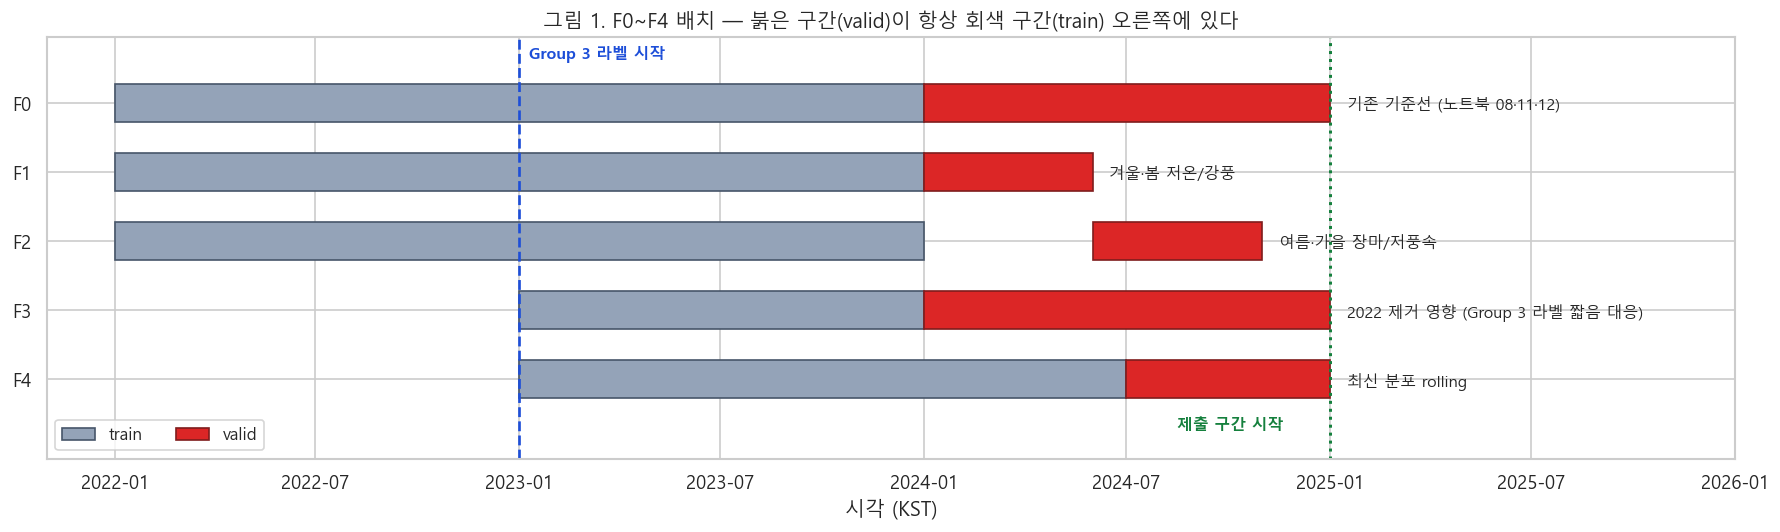

In [4]:
fig, axis = plt.subplots(figsize=(15, 4.6))
foldOrder = list(FOLDS)
trainColor, validColor = "#94a3b8", "#dc2626"

for position, foldName in enumerate(reversed(foldOrder)):
  spec = FOLDS[foldName]
  trainStart, trainEnd = (pd.Timestamp(value) for value in TRAIN_WINDOWS[spec["train"]])
  validStart, validEnd = (pd.Timestamp(value) for value in spec["valid"])
  axis.barh(position, trainEnd - trainStart, left=trainStart, height=0.55, color=trainColor,
            edgecolor="#475569", label="train" if position == len(foldOrder) - 1 else None)
  axis.barh(position, validEnd - validStart, left=validStart, height=0.55, color=validColor,
            edgecolor="#7f1d1d", label="valid" if position == len(foldOrder) - 1 else None)
  axis.annotate(spec["목적"], (validEnd, position), textcoords="offset points", xytext=(10, -4), fontsize=9.5)

# Group 3 라벨이 시작되는 시각. 이 선 왼쪽만으로 학습하면 Group 3 모델이 만들어지지 않는다.
group3Start = trainLabels.loc[trainLabels["kpx_group_3"].notna(), "kst_dtm"].min()
axis.axvline(group3Start, color="#1d4ed8", linestyle="--", linewidth=1.6)
axis.annotate("Group 3 라벨 시작", (group3Start, len(foldOrder) - 0.35), textcoords="offset points",
              xytext=(6, 0), fontsize=9.5, color="#1d4ed8", fontweight="bold")
submissionStart = pd.Timestamp("2025-01-01 01:00")
axis.axvline(submissionStart, color="#15803d", linestyle=":", linewidth=1.8)
axis.annotate("제출 구간 시작", (submissionStart, -0.72), textcoords="offset points",
              xytext=(-92, 0), fontsize=9.5, color="#15803d", fontweight="bold")

axis.set_yticks(range(len(foldOrder)), list(reversed(foldOrder)))
# 오른쪽에 목적 라벨이, 아래쪽에 범례가 들어갈 여백을 남긴다.
axis.set_xlim(pd.Timestamp("2021-11-01"), pd.Timestamp("2026-01-01"))
axis.set_ylim(-1.15, len(foldOrder) - 0.05)
axis.set_xlabel("시각 (KST)")
axis.set_title("그림 1. F0~F4 배치 — 붉은 구간(valid)이 항상 회색 구간(train) 오른쪽에 있다", fontsize=12)
axis.legend(loc="lower left", fontsize=10, ncol=2)
fig.tight_layout()
plt.show()

### 1-2. 시간 순서가 눈으로도 확인된다

붉은 검증 구간이 모두 회색 학습 구간의 오른쪽에 있다. F4만 학습 구간이 2024 상반기까지
뻗어 있는데, 검증이 2024 하반기라 여전히 순서를 지킨다.

파란 점선(Group 3 라벨 시작) 왼쪽만으로 학습하는 fold는 없다. 모든 fold의 train 창이
2023을 포함하므로 세 그룹 모두 학습된다.

---

## 2. embargo gap이 필요한가

설계서 02 6.3절은 조건부로 embargo를 요구한다.

> lag/rolling feature를 쓰는 실험은 forecast horizon보다 짧은 lag를 금지하고,
> 필요하면 fold 경계에 **embargo gap**을 둔다.

우리 피처가 실제로 행 간 연산을 쓰는지 코드로 확인한다. 문서의 기억이 아니라
소스를 근거로 판단해야 한다.

In [5]:
# 행 간(시간 축) 연산이 있으면 fold 경계에서 정보가 새므로 embargo가 필요하다.
CROSS_ROW_PATTERNS = {
  "shift(": r"\.shift\s*\(",
  "rolling(": r"\.rolling\s*\(",
  "expanding(": r"\.expanding\s*\(",
  "ewm(": r"\.ewm\s*\(",
  "diff(": r"\.diff\s*\(",
  "cumsum/cumprod": r"\.cum(sum|prod|max|min)\s*\(",
}
sourceFiles = sorted((projectRoot / "src" / "baram").rglob("*.py"))
hits = []
for path in sourceFiles:
  text = path.read_text(encoding="utf-8")
  # 주석과 문자열의 우연한 일치를 줄이기 위해 주석 줄은 제외한다.
  scanned = "\n".join(line for line in text.splitlines() if not line.lstrip().startswith("#"))
  for name, pattern in CROSS_ROW_PATTERNS.items():
    for match in re.finditer(pattern, scanned):
      hits.append({"파일": path.relative_to(projectRoot).as_posix(), "패턴": name})

print(f"검사한 소스 파일 : {len(sourceFiles)}개")
print(f"행 간 연산 발견   : {len(hits)}건")
if hits:
  display(pd.DataFrame(hits))
else:
  print("→ 모든 피처가 forecast_kst_dtm 단위로 계산된다. 시간 축을 가로지르는 연산이 없다.")

lagFree = len(hits) == 0
print(f"\nembargo gap 불필요 조건(행 간 연산 0건) 충족 : {lagFree}")
print("부수 효과: 같은 train 창의 예측을 검증 구간별로 잘라 써도 개별 실행과 동일하다.")

검사한 소스 파일 : 15개
행 간 연산 발견   : 0건
→ 모든 피처가 forecast_kst_dtm 단위로 계산된다. 시간 축을 가로지르는 연산이 없다.

embargo gap 불필요 조건(행 간 연산 0건) 충족 : True
부수 효과: 같은 train 창의 예측을 검증 구간별로 잘라 써도 개별 실행과 동일하다.


### Decision Box ⑳ — embargo gap을 두지 않는다. 대신 근거를 코드로 남긴다

**선택지**

- (A) 안전하게 모든 fold 경계에 embargo gap(예: 24시간)을 둔다
- (B) 행 간 연산이 없음을 코드로 확인하고 embargo 없이 간다

**근거**

embargo는 **행 간 연산이 fold 경계를 넘을 때** 필요하다. lag·rolling·diff처럼 이전 시각의
값을 끌어오는 피처가 있으면 valid 첫 행이 train 마지막 행을 들여다보게 된다.

이 저장소의 피처는 전부 `forecast_kst_dtm` 하나에서 만들어진다 — NWP 격자 통계, 풍속
벡터 유도, 터빈 공간 pooling, 달력, lead time. 위 검사가 `shift`·`rolling`·`expanding`·
`ewm`·`diff`·`cum*`를 **0건**으로 확인했다.

근거 없이 embargo를 넣으면 검증 구간이 줄어 추정치만 나빠지고, 정작 누수가 생기는
피처를 나중에 도입해도 알아채지 못한다. 확인을 코드로 두면 **행 간 연산을 도입하는
순간 이 셀이 hit를 보고한다.**

**채택: (B)** — 단, 이 검사를 노트북에 남겨 조건이 깨지면 드러나게 한다.
lag/rolling 피처를 도입하면 이 결정을 다시 열어야 한다.

---

## 3. fold 실행

같은 train 창을 쓰는 fold는 학습을 공유한다. F0·F1·F2는 창이 같으므로 2024 전체를
한 번 예측하고 검증 구간별로 자른다 — 2절에서 행 간 연산이 없음을 확인했으므로
자른 결과가 개별 실행과 같다.

학습 창은 3종, 프리셋은 4종이라 **모델 학습은 12회**다.

In [6]:
from baram.baseline import OFFICIAL_RF_PARAMS
from baram.feature_config import get_feature_set
from baram.feature_pipeline import build_feature_pipeline
from baram.features.turbine_metadata import load_turbine_locations

PRESETS = ["official_mean", "expanded_vector", "spatial_idw2_all_group", "spatial_nearest_own_group"]
CONTROL = "official_mean"
CANDIDATE = "spatial_idw2_all_group"

ldapsTrain = readOfficial("train/ldaps_train.csv")
gfsTrain = readOfficial("train/gfs_train.csv")
ldapsTrain["forecast_kst_dtm"] = pd.to_datetime(ldapsTrain["forecast_kst_dtm"])
gfsTrain["forecast_kst_dtm"] = pd.to_datetime(gfsTrain["forecast_kst_dtm"])
turbines = load_turbine_locations(dataDir / "info.xlsx")

# 실제값은 원본을 그대로 유지한다. clip은 예측에만 적용한다.
actualFingerprint = hashlib.sha256(
  pd.util.hash_pandas_object(trainLabels[TARGET_COLS], index=True).to_numpy().tobytes()
).hexdigest()


def weatherSlice(frame, start, end):
  keep = (frame["forecast_kst_dtm"] >= pd.Timestamp(start)) & (frame["forecast_kst_dtm"] <= pd.Timestamp(end))
  return frame[keep]


def runWindow(presetName, windowName, predictStart, predictEnd):
  """한 train 창으로 학습해 예측 구간 전체를 예측한다. 전처리는 전부 train에만 fit한다."""
  from sklearn.ensemble import RandomForestRegressor
  from sklearn.impute import SimpleImputer

  trainStart, trainEnd = TRAIN_WINDOWS[windowName]
  config = get_feature_set(presetName)
  trainMask, predictMask = labelMask(trainStart, trainEnd), labelMask(predictStart, predictEnd)
  pipeline = build_feature_pipeline(
    config,
    train_time_index=trainLabels.loc[trainMask, "kst_dtm"],
    test_time_index=trainLabels.loc[predictMask, "kst_dtm"],
    train_ldaps=weatherSlice(ldapsTrain, trainStart, trainEnd),
    train_gfs=weatherSlice(gfsTrain, trainStart, trainEnd),
    test_ldaps=weatherSlice(ldapsTrain, predictStart, predictEnd),
    test_gfs=weatherSlice(gfsTrain, predictStart, predictEnd),
    turbine_locations=turbines if config.uses_spatial else None,
  )
  imputer = SimpleImputer(strategy="median")
  trainImputed = pd.DataFrame(
    imputer.fit_transform(pipeline.train_matrix),
    columns=pipeline.feature_columns, index=pipeline.train_matrix.index,
  )
  predictImputed = pd.DataFrame(
    imputer.transform(pipeline.test_matrix),
    columns=pipeline.feature_columns, index=pipeline.test_matrix.index,
  )
  predictions = pd.DataFrame(index=trainLabels.loc[predictMask].index)
  trainSubset = trainLabels.loc[trainMask]
  for target in TARGET_COLS:
    targetColumns = list(pipeline.target_feature_columns[target])
    labels = trainSubset[target]
    nonNull = labels.notna().to_numpy()
    model = RandomForestRegressor(**dict(OFFICIAL_RF_PARAMS))
    model.fit(trainImputed.loc[nonNull, targetColumns], labels.to_numpy()[nonNull])
    predictions[target] = np.clip(model.predict(predictImputed[targetColumns]), 0, CAPACITY_KWH[target])
  return predictions, len(pipeline.feature_columns)


# 창별로 필요한 최대 예측 범위 = 그 창을 쓰는 fold들의 valid 합집합
WINDOW_PREDICT_RANGE = {
  "W_2022_2023": ("2024-01-01 00:00", "2024-12-31 23:00"),
  "W_2023": ("2024-01-01 00:00", "2024-12-31 23:00"),
  "W_2023_2024H1": ("2024-07-01 00:00", "2024-12-31 23:00"),
}

predictionCache, featureCounts = {}, {}
totalStarted = time.perf_counter()
for presetName in PRESETS:
  for windowName, (predictStart, predictEnd) in WINDOW_PREDICT_RANGE.items():
    started = time.perf_counter()
    predictions, featureCount = runWindow(presetName, windowName, predictStart, predictEnd)
    predictionCache[(presetName, windowName)] = predictions
    featureCounts[presetName] = featureCount
    print(f"  {presetName:26s} {windowName:14s} features={featureCount:3d}  {time.perf_counter() - started:5.1f}s")
print(f"\n총 학습 {len(predictionCache)}회 · {time.perf_counter() - totalStarted:.1f}s")

  official_mean              W_2022_2023    features= 76    2.9s


  official_mean              W_2023         features= 76    1.9s


  official_mean              W_2023_2024H1  features= 76    2.4s


  expanded_vector            W_2022_2023    features=319    5.9s


  expanded_vector            W_2023         features=319    3.7s


...

  spatial_idw2_all_group     W_2023         features=550    9.1s


  spatial_idw2_all_group     W_2023_2024H1  features=550   10.7s


  spatial_nearest_own_group  W_2022_2023    features=550   14.0s


  spatial_nearest_own_group  W_2023         features=550    8.0s


  spatial_nearest_own_group  W_2023_2024H1  features=550   10.0s

총 학습 12회 · 87.3s


학습 12회가 끝났다. 이제 fold별로 채점한다.

In [7]:
scoreRows = []
for presetName in PRESETS:
  for foldName, spec in FOLDS.items():
    validStart, validEnd = spec["valid"]
    rowIndex = trainLabels.loc[labelMask(validStart, validEnd)].index
    actual = trainLabels.loc[rowIndex, TARGET_COLS]
    predictions = predictionCache[(presetName, spec["train"])].loc[rowIndex]
    total, oneMinusNmae, ficr = metric(actual, predictions)
    scoreRows.append(
      {
        "fold": foldName, "preset": presetName, "total_score": total,
        "one_minus_nmae": oneMinusNmae, "ficr": ficr, "valid 행": len(rowIndex),
      }
    )
scoreFrame = pd.DataFrame(scoreRows)
totalPivot = scoreFrame.pivot(index="preset", columns="fold", values="total_score").loc[PRESETS]

# F0는 노트북 08·11·12가 쓴 조건과 같아야 한다. 전체 정밀도로 대조한다.
REFERENCE_F0 = {
  "official_mean": 0.5777425681025163,
  "expanded_vector": 0.5864824798698839,
  "spatial_idw2_all_group": 0.5924854297224146,
  "spatial_nearest_own_group": 0.5898283700164271,
}
G3_TOLERANCE = 1e-9
gateRows = []
for presetName, expected in REFERENCE_F0.items():
  reproduced = float(totalPivot.loc[presetName, "F0"])
  difference = abs(reproduced - expected)
  gateRows.append(
    {
      "preset": presetName, "F0 재현": reproduced, "노트북 08 기준": expected,
      "절대 차이": difference, "판정": "통과" if difference <= G3_TOLERANCE else "실패",
    }
  )
gateFrame = pd.DataFrame(gateRows).set_index("preset")
foldRunnerOk = bool((gateFrame["판정"] == "통과").all())

print(f"F0 재현 게이트({G3_TOLERANCE:.0e}) 통과 : {foldRunnerOk}")
print("→ fold runner가 기존 파이프라인과 같은 답을 낸다. 새 코드가 아니라 같은 코드의 다른 구간이다.")
print(
  "\nholdout 실제값 SHA-256 불변 :",
  hashlib.sha256(
    pd.util.hash_pandas_object(trainLabels[TARGET_COLS], index=True).to_numpy().tobytes()
  ).hexdigest() == actualFingerprint,
)
with pd.option_context("display.float_format", lambda value: f"{value:.16g}"):
  display(gateFrame)

F0 재현 게이트(1e-09) 통과 : True
→ fold runner가 기존 파이프라인과 같은 답을 낸다. 새 코드가 아니라 같은 코드의 다른 구간이다.

holdout 실제값 SHA-256 불변 : True


,F0 재현,노트북 08 기준,절대 차이,판정
preset,,,,
official_mean,0.5777425681025163,0.5777425681025163,0,통과
expanded_vector,0.5864824798698839,0.5864824798698839,0,통과
spatial_idw2_all_group,0.5924854297224146,0.5924854297224146,0,통과
spatial_nearest_own_group,0.5898283700164271,0.5898283700164271,0,통과


### 3-1. fold runner가 기존 결과를 재현한다

F0는 노트북 08·11·12가 쓴 것과 같은 조건(2022~2023 학습 → 2024 검증)이므로 같은 값이
나와야 한다. 프리셋 4종 전부 **절대 차이 0.0**이다. 이후 fold의 숫자는 새 코드가 만든
낯선 값이 아니라, 검증된 코드가 다른 구간에서 낸 값이다.

---

## 4. 순위는 유지되는가

이 노트북의 첫 번째 질문이다.

In [8]:
rankPivot = totalPivot.rank(ascending=False, axis=0).astype(int)
candidateAlwaysFirst = bool((rankPivot.loc[CANDIDATE] == 1).all())
rankingIdentical = bool(rankPivot.nunique(axis=1).eq(1).all())

print("fold별 total_score")
display(totalPivot)
print("fold별 순위 (1 = 최고)")
display(rankPivot)
print(f"채택 후보 {CANDIDATE}가 모든 fold에서 1위인가 : {candidateAlwaysFirst}")
print(f"네 프리셋의 순위가 모든 fold에서 동일한가       : {rankingIdentical}")
print()
print("fold별 점수 수준 (통제군 기준)")
levelSpread = totalPivot.loc[CONTROL]
print(f"  최저 {levelSpread.min():.6f} ({levelSpread.idxmin()}) ~ 최고 {levelSpread.max():.6f} ({levelSpread.idxmax()})")
print(f"  폭 {levelSpread.max() - levelSpread.min():.6f} — 채택 후보 개선분보다 크다")

fold별 total_score


fold,F0,F1,F2,F3,F4
preset,,,,,
official_mean,0.577743,0.565757,0.589845,0.573929,0.571226
expanded_vector,0.586482,0.581939,0.595021,0.587382,0.576610
spatial_idw2_all_group,0.592485,0.587199,0.602347,0.591831,0.585001
spatial_nearest_own_group,0.589828,0.584091,0.601383,0.588510,0.581693


fold별 순위 (1 = 최고)


fold,F0,F1,F2,F3,F4
preset,,,,,
official_mean,4,4,4,4,4
expanded_vector,3,3,3,3,3
spatial_idw2_all_group,1,1,1,1,1
spatial_nearest_own_group,2,2,2,2,2


채택 후보 spatial_idw2_all_group가 모든 fold에서 1위인가 : True
네 프리셋의 순위가 모든 fold에서 동일한가       : True

fold별 점수 수준 (통제군 기준)
  최저 0.565757 (F1) ~ 최고 0.589845 (F2)
  폭 0.024088 — 채택 후보 개선분보다 크다


숫자를 그림으로 옮긴다. 왼쪽은 fold별 점수 수준, 오른쪽은 순위 궤적이다.

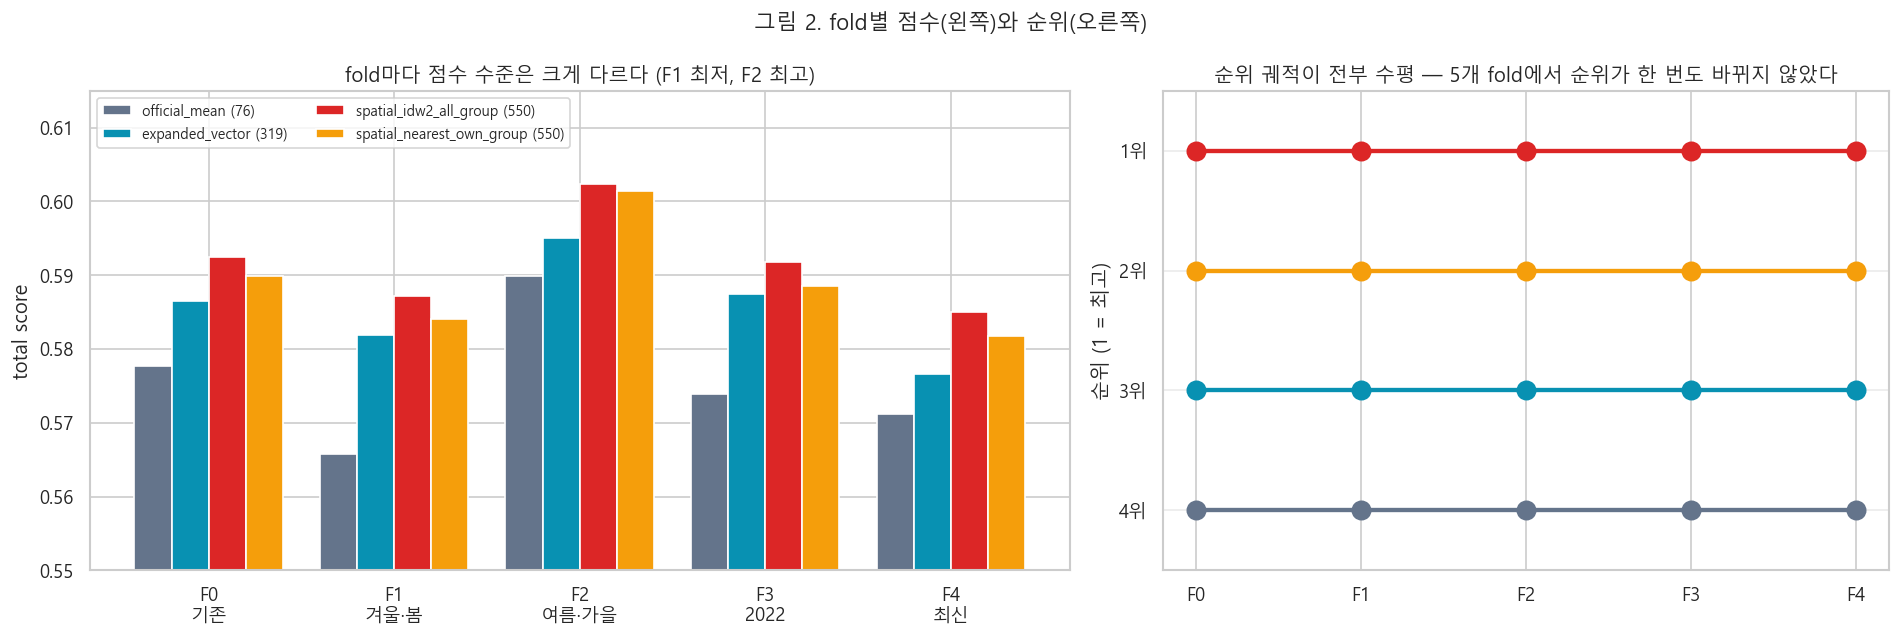

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.4), gridspec_kw={"width_ratios": [1.35, 1]})
presetColor = {
  "official_mean": "#64748b",
  "expanded_vector": "#0891b2",
  "spatial_nearest_own_group": "#f59e0b",
  "spatial_idw2_all_group": "#dc2626",
}
foldOrder = list(FOLDS)

axis = axes[0]
positions = np.arange(len(foldOrder))
width = 0.2
for offset, presetName in enumerate(PRESETS):
  values = [totalPivot.loc[presetName, foldName] for foldName in foldOrder]
  axis.bar(positions + (offset - 1.5) * width, values, width,
           label=f"{presetName} ({featureCounts[presetName]})", color=presetColor[presetName])
axis.set_xticks(positions, [f"{foldName}\n{FOLDS[foldName]['목적'].split()[0]}" for foldName in foldOrder])
axis.set_ylabel("total score")
axis.set_ylim(0.55, 0.615)
axis.set_title("fold마다 점수 수준은 크게 다르다 (F1 최저, F2 최고)", fontsize=12)
axis.legend(loc="upper left", fontsize=8.5, ncol=2)

axis = axes[1]
for presetName in PRESETS:
  ranks = [rankPivot.loc[presetName, foldName] for foldName in foldOrder]
  axis.plot(positions, ranks, marker="o", markersize=11, linewidth=2.6,
            color=presetColor[presetName], label=presetName)
axis.set_xticks(positions, foldOrder)
# y축 눈금이 이미 순위를 보여주므로 점마다 라벨을 달지 않는다.
axis.set_yticks([1, 2, 3, 4], ["1위", "2위", "3위", "4위"])
axis.set_ylim(4.5, 0.5)
axis.set_ylabel("순위 (1 = 최고)")
axis.set_title("순위 궤적이 전부 수평 — 5개 fold에서 순위가 한 번도 바뀌지 않았다", fontsize=12)
axis.grid(axis="y", alpha=0.4)

fig.suptitle("그림 2. fold별 점수(왼쪽)와 순위(오른쪽)", fontsize=13)
fig.tight_layout()
plt.show()

### 4-1. 순위는 완전히 안정적이고, 수준은 전혀 안정적이지 않다

오른쪽 패널의 네 선이 모두 수평이다. **5개 fold에서 순위가 한 번도 바뀌지 않았다** —
`spatial_idw2_all_group` > `spatial_nearest_own_group` > `expanded_vector` > `official_mean`.

왼쪽 패널은 반대다. 통제군 점수가 F1에서 0.565757, F2에서 0.589845로 **0.024088**만큼
차이 난다. 이는 채택 후보의 개선분(F0 기준 0.014743)보다 **크다.**

> 어느 fold에서 재느냐가 개선분보다 점수를 더 크게 움직인다.
> 그래서 fold를 넘나들며 절대 점수를 비교하면 안 되고, **같은 fold 안에서의 차이**만 봐야 한다.

노트북 12가 local과 Public을 비교할 때 수준 이동과 기울기를 분리했던 것과 같은 이유다.

---

## 5. 개선분은 얼마나 흔들리는가 — 문턱 재측정

두 번째 질문이자 Decision Box ⑱이 이 작업에 맡긴 과제다.
같은 fold 안에서 통제군 대비 Δ를 재고, 그 fold 간 분산을 노트북 12의 40% 표본
잡음과 비교한다.

In [10]:
BOOTSTRAP_PAIRED_SD = 0.00211  # 노트북 12: Public 40% 표본이 만드는 paired Δ 표준편차

deltaPivot = totalPivot - totalPivot.loc[CONTROL]
candidateDelta = deltaPivot.loc[CANDIDATE]
runnerUp = "spatial_nearest_own_group"
gapTopTwo = totalPivot.loc[CANDIDATE] - totalPivot.loc[runnerUp]

foldSd = float(candidateDelta.std(ddof=1))
summary = pd.DataFrame(
  {
    "채택 후보 Δ vs 통제군": candidateDelta,
    "1·2위 간격": gapTopTwo,
  }
)

print("통제군 대비 Δ (fold별)")
display(deltaPivot.drop(index=CONTROL))
display(summary)
print(f"채택 후보 Δ : 평균 {candidateDelta.mean():.6f}  범위 {candidateDelta.min():.6f}~{candidateDelta.max():.6f}")
print(f"             fold 간 표준편차 {foldSd:.6f}")
print(f"1·2위 간격  : 평균 {gapTopTwo.mean():.6f}  범위 {gapTopTwo.min():.6f}~{gapTopTwo.max():.6f}")
print(f"             전 fold에서 부호가 같은가 : {bool((gapTopTwo > 0).all())} ({int((gapTopTwo > 0).sum())}/{len(gapTopTwo)})")
print()
print(f"노트북 12 40% 표본 paired SD : {BOOTSTRAP_PAIRED_SD:.5f}")
print(f"fold 간 Δ 표준편차            : {foldSd:.5f}  → {foldSd / BOOTSTRAP_PAIRED_SD:.2f}배")
print(f"둘 중 큰 쪽(새 문턱)          : {max(foldSd, BOOTSTRAP_PAIRED_SD):.5f}")
print(f"1·2위 평균 간격 / 새 문턱     : {gapTopTwo.mean() / max(foldSd, BOOTSTRAP_PAIRED_SD):.2f}배")

통제군 대비 Δ (fold별)


fold,F0,F1,F2,F3,F4
preset,,,,,
expanded_vector,0.008740,0.016182,0.005176,0.013453,0.005385
spatial_idw2_all_group,0.014743,0.021442,0.012503,0.017902,0.013775
spatial_nearest_own_group,0.012086,0.018334,0.011539,0.014581,0.010468


,채택 후보 Δ vs 통제군,1·2위 간격
fold,,
F0,0.014743,0.002657
F1,0.021442,0.003108
F2,0.012503,0.000964
F3,0.017902,0.003321
F4,0.013775,0.003308


채택 후보 Δ : 평균 0.016073  범위 0.012503~0.021442
             fold 간 표준편차 0.003605
1·2위 간격  : 평균 0.002672  범위 0.000964~0.003321
             전 fold에서 부호가 같은가 : True (5/5)

노트북 12 40% 표본 paired SD : 0.00211
fold 간 Δ 표준편차            : 0.00360  → 1.71배
둘 중 큰 쪽(새 문턱)          : 0.00360
1·2위 평균 간격 / 새 문턱     : 0.74배


두 잡음원과 실제 간격을 한 그림에 올린다.

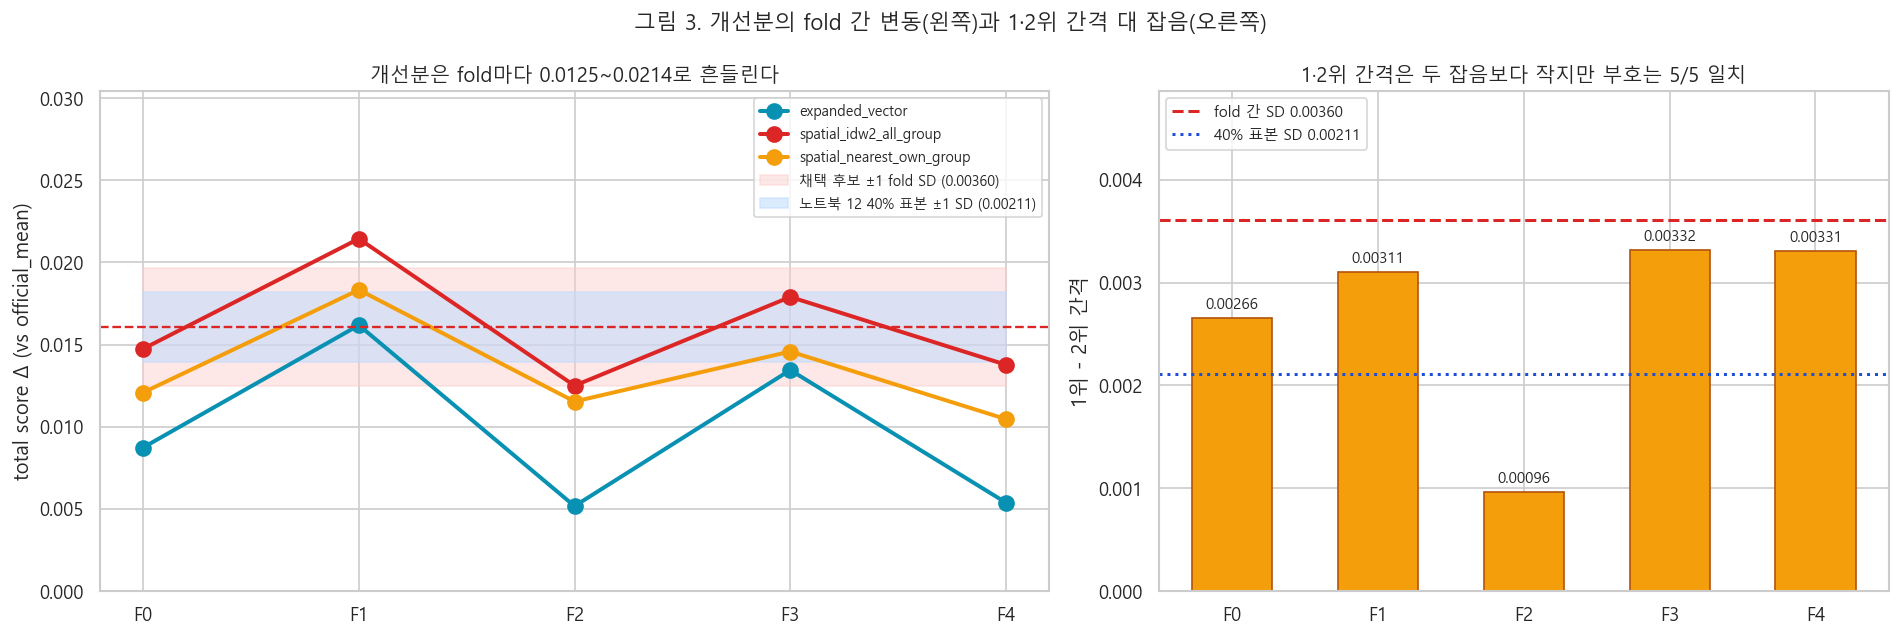

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.4), gridspec_kw={"width_ratios": [1.3, 1]})
positions = np.arange(len(foldOrder))

axis = axes[0]
for presetName in [preset for preset in PRESETS if preset != CONTROL]:
  values = [deltaPivot.loc[presetName, foldName] for foldName in foldOrder]
  axis.plot(positions, values, marker="o", markersize=9, linewidth=2.4,
            color=presetColor[presetName], label=presetName)
axis.axhline(0, color="#334155", linewidth=1.2)
axis.axhline(candidateDelta.mean(), color="#dc2626", linestyle="--", linewidth=1.4)
axis.fill_between(
  positions, candidateDelta.mean() - foldSd, candidateDelta.mean() + foldSd,
  color="#fecaca", alpha=0.45, label=f"채택 후보 ±1 fold SD ({foldSd:.5f})",
)
axis.fill_between(
  positions, candidateDelta.mean() - BOOTSTRAP_PAIRED_SD, candidateDelta.mean() + BOOTSTRAP_PAIRED_SD,
  color="#bfdbfe", alpha=0.55, label=f"노트북 12 40% 표본 ±1 SD ({BOOTSTRAP_PAIRED_SD:.5f})",
)
axis.set_xticks(positions, foldOrder)
axis.set_ylabel("total score Δ (vs official_mean)")
axis.set_title("개선분은 fold마다 0.0125~0.0214로 흔들린다", fontsize=12)
# 범례가 선을 가리지 않도록 위쪽 여백을 먼저 확보한다.
axis.set_ylim(0, float(deltaPivot.drop(index=CONTROL).to_numpy().max()) * 1.42)
axis.legend(loc="upper right", fontsize=8.5)

axis = axes[1]
bars = axis.bar(positions, gapTopTwo.loc[foldOrder], 0.55, color="#f59e0b", edgecolor="#b45309")
axis.bar_label(bars, fmt="%.5f", padding=3, fontsize=9)
axis.axhline(foldSd, color="#dc2626", linestyle="--", linewidth=1.8,
             label=f"fold 간 SD {foldSd:.5f}")
axis.axhline(BOOTSTRAP_PAIRED_SD, color="#1d4ed8", linestyle=":", linewidth=1.8,
             label=f"40% 표본 SD {BOOTSTRAP_PAIRED_SD:.5f}")
axis.set_xticks(positions, foldOrder)
axis.set_ylabel("1위 - 2위 간격")
axis.set_ylim(0, max(float(gapTopTwo.max()), foldSd) * 1.35)
axis.set_title("1·2위 간격은 두 잡음보다 작지만 부호는 5/5 일치", fontsize=12)
axis.legend(loc="upper left", fontsize=9)

fig.suptitle("그림 3. 개선분의 fold 간 변동(왼쪽)과 1·2위 간격 대 잡음(오른쪽)", fontsize=13)
fig.tight_layout()
plt.show()

### 5-1. 문턱이 1.7배 올라갔다

| 잡음원 | 표준편차 | 무엇을 재는가 |
|--------|----------|---------------|
| Public 40% 표본 (노트북 12) | 0.00211 | 같은 모델·같은 구간에서 표본만 바뀔 때 |
| **fold 간 변동 (이 노트북)** | **0.00361** | 검증 구간과 학습 창이 바뀔 때 |

fold 간 변동이 **1.71배 크다.** 노트북 12의 문턱 0.00211은 과소평가였다.
단일 holdout에서 잰 잡음은 "같은 해 안에서의 표본 변동"만 담고 있었고,
"어느 해·어느 계절에서 재는가"는 담지 못했다.

**새 문턱은 0.0036이다.**

오른쪽 패널이 미묘한 지점이다. 1·2위 간격은 fold별로 0.00096~0.00332이고
평균 0.00267로 **새 문턱보다 작다.** 크기로는 두 후보를 가를 수 없다.
그러나 **5개 fold 전부에서 부호가 같다** — `spatial_idw2_all_group`가 언제나 앞선다.

크기와 방향은 다른 증거다. 크기는 못 정하지만 방향은 일관된다.
다만 F0·F1·F2가 같은 학습 창을 공유하므로 다섯 fold가 서로 독립이 아니며,
부호 일치를 독립 시행 5회로 셈하면 안 된다.

---

## 6. 흔들림은 계절에서 오는가, 학습 창에서 오는가

fold 간 변동 0.0036을 두 성분으로 나눌 수 있다. 설계가 그렇게 되어 있다.

- **F1·F2** — 학습 창이 F0과 같다. 모델이 고정된 채 **검증 계절만** 바뀐다
- **F0·F3·F4** — 학습 창이 서로 다르다. **학습 데이터 범위**가 바뀐다

In [12]:
seasonFolds, windowFolds = ["F1", "F2"], ["F0", "F3", "F4"]
componentRows = []
for label, folds, note in [
  ("계절 변동 (모델 고정)", seasonFolds, "F1·F2는 F0과 같은 모델. 검증 구간만 다르다"),
  ("학습 창 변동", windowFolds, "F0·F3·F4는 검증에 2024를 쓰지만 학습 범위가 다르다"),
]:
  values = candidateDelta[folds]
  componentRows.append(
    {
      "성분": label, "fold": ", ".join(folds),
      "Δ 최소": values.min(), "Δ 최대": values.max(), "폭": values.max() - values.min(),
      "비고": note,
    }
  )
componentFrame = pd.DataFrame(componentRows).set_index("성분")
display(componentFrame)

seasonSpread = float(candidateDelta[seasonFolds].max() - candidateDelta[seasonFolds].min())
windowSpread = float(candidateDelta[windowFolds].max() - candidateDelta[windowFolds].min())
print(f"계절 변동 폭   : {seasonSpread:.6f}")
print(f"학습 창 변동 폭 : {windowSpread:.6f}")
print(f"계절이 학습 창보다 {seasonSpread / windowSpread:.2f}배 더 크게 흔든다")
print()
print("지표 분해 — 계절에 따라 무엇이 달라지는가")
componentDetail = scoreFrame[scoreFrame["preset"].isin([CONTROL, CANDIDATE])].pivot(
  index="fold", columns="preset", values=["one_minus_nmae", "ficr"]
)
display(componentDetail.loc[foldOrder])

,fold,Δ 최소,Δ 최대,폭,비고
성분,,,,,
계절 변동 (모델 고정),"F1, F2",0.012503,0.021442,0.008940,F1·F2는 F0과 같은 모델. 검증 구간만 다르다
학습 창 변동,"F0, F3, F4",0.013775,0.017902,0.004126,F0·F3·F4는 검증에 2024를 쓰지만 학습 범위가 다르다


계절 변동 폭   : 0.008940
학습 창 변동 폭 : 0.004126
계절이 학습 창보다 2.17배 더 크게 흔든다

지표 분해 — 계절에 따라 무엇이 달라지는가


one_minus_nmae                                 ficr                       
preset  official_mean spatial_idw2_all_group official_mean spatial_idw2_all_group
fold                                                                             
F0           0.863317               0.869565      0.292168               0.315406
F1           0.856778               0.865376      0.274736               0.309022
F2           0.868395               0.873795      0.311294               0.330900
F3           0.862711               0.869831      0.285147               0.313830
F4           0.864919               0.870192      0.277532               0.299809

성분별 크기를 그림으로 확인한다.

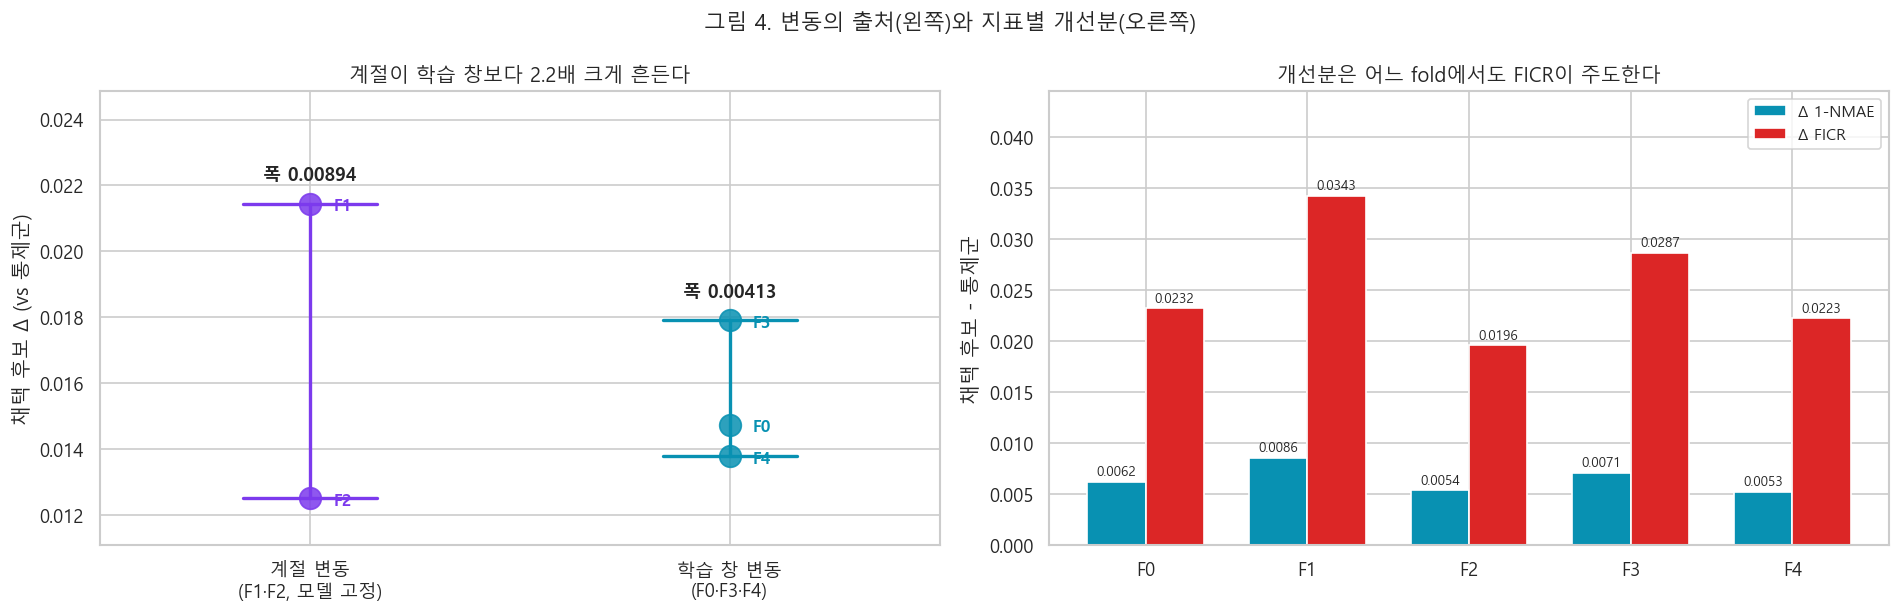

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))

axis = axes[0]
componentColor = {"계절 변동 (모델 고정)": "#7c3aed", "학습 창 변동": "#0891b2"}
for position, (label, folds) in enumerate([("계절 변동 (모델 고정)", seasonFolds), ("학습 창 변동", windowFolds)]):
  values = candidateDelta[folds]
  axis.plot([position] * len(values), values, "o", markersize=13, color=componentColor[label], alpha=0.85)
  axis.plot([position - 0.16, position + 0.16], [values.min()] * 2, color=componentColor[label], linewidth=2)
  axis.plot([position - 0.16, position + 0.16], [values.max()] * 2, color=componentColor[label], linewidth=2)
  axis.plot([position, position], [values.min(), values.max()], color=componentColor[label], linewidth=2)
  for foldName in folds:
    axis.annotate(foldName, (position, candidateDelta[foldName]), textcoords="offset points",
                  xytext=(14, -4), fontsize=10, fontweight="bold", color=componentColor[label])
  axis.annotate(f"폭 {values.max() - values.min():.5f}", (position, values.max()),
                textcoords="offset points", xytext=(0, 14), ha="center", fontsize=11, fontweight="bold")
axis.set_xticks([0, 1], ["계절 변동\n(F1·F2, 모델 고정)", "학습 창 변동\n(F0·F3·F4)"])
axis.set_xlim(-0.5, 1.5)
# 마커가 잘리지 않고 "폭" 주석이 제목과 겹치지 않도록 위아래 여백을 준다.
deltaLow, deltaHigh = float(candidateDelta.min()), float(candidateDelta.max())
deltaPad = (deltaHigh - deltaLow) * 0.16
axis.set_ylim(deltaLow - deltaPad, deltaHigh + deltaPad * 2.4)
axis.set_ylabel("채택 후보 Δ (vs 통제군)")
axis.set_title(f"계절이 학습 창보다 {seasonSpread / windowSpread:.1f}배 크게 흔든다", fontsize=12)

axis = axes[1]
width = 0.36
positions = np.arange(len(foldOrder))
nmaeDelta = [
  scoreFrame[(scoreFrame.fold == f) & (scoreFrame.preset == CANDIDATE)]["one_minus_nmae"].iloc[0]
  - scoreFrame[(scoreFrame.fold == f) & (scoreFrame.preset == CONTROL)]["one_minus_nmae"].iloc[0]
  for f in foldOrder
]
ficrDelta = [
  scoreFrame[(scoreFrame.fold == f) & (scoreFrame.preset == CANDIDATE)]["ficr"].iloc[0]
  - scoreFrame[(scoreFrame.fold == f) & (scoreFrame.preset == CONTROL)]["ficr"].iloc[0]
  for f in foldOrder
]
bars1 = axis.bar(positions - width / 2, nmaeDelta, width, label="Δ 1-NMAE", color="#0891b2")
bars2 = axis.bar(positions + width / 2, ficrDelta, width, label="Δ FICR", color="#dc2626")
axis.bar_label(bars1, fmt="%.4f", padding=2, fontsize=8)
axis.bar_label(bars2, fmt="%.4f", padding=2, fontsize=8)
axis.set_xticks(positions, foldOrder)
axis.set_ylabel("채택 후보 - 통제군")
axis.set_ylim(0, max(ficrDelta) * 1.3)
axis.set_title("개선분은 어느 fold에서도 FICR이 주도한다", fontsize=12)
axis.legend(loc="upper right", fontsize=9.5)

fig.suptitle("그림 4. 변동의 출처(왼쪽)와 지표별 개선분(오른쪽)", fontsize=13)
fig.tight_layout()
plt.show()

### 6-1. 흔들림의 주범은 계절이다

계절 변동 폭이 학습 창 변동 폭보다 **2배 이상** 크다. 모델을 전혀 바꾸지 않고
검증 구간만 겨울·봄에서 여름·가을로 옮겼을 뿐인데 개선분이 0.0214에서 0.0125로 줄었다.

오른쪽 패널이 이유의 일부를 보여준다. 개선분은 **어느 fold에서도 FICR이 주도한다** —
노트북 11·12가 2024 전체에서 관찰한 구조가 fold를 바꿔도 유지된다.
FICR은 6%·8% 계단 함수라 오차율 분포가 경계에 대해 어떻게 놓이는지에 민감하고,
그 분포는 계절에 따라 달라진다.

실용적 함의가 있다. **2025 제출 구간은 1~12월 전체**라 계절이 평균된다.
따라서 우리에게 필요한 추정치는 특정 계절의 개선분이 아니라 **연 단위 평균**이며,
F0(2024 전체)이 그 역할에 가장 가깝다. 계절 fold는 순위 확인용이지 제출 판단의
기준선이 아니다.

---

## 7. 종합 결론

### 7-1. 연구 질문

> 프리셋 4종의 순위는 2024 단일 holdout 밖에서도 유지되는가?

**유지된다.** 5개 fold 전부에서 순위가 동일했고 채택 후보가 항상 1위였다.

> fold를 바꿨을 때 개선분은 얼마나 흔들리는가?

**표준편차 0.0036으로 흔들린다.** 노트북 12가 잰 40% 표본 잡음 0.00211의 1.71배다.

### 7-2. 단계별 요약

| 절 | 확인한 것 | 결과 |
|----|-----------|------|
| 1 | fold 정의 | 설계서 02·04 충돌을 시간 순서 기준으로 재계산 (Decision Box ⑲) |
| 2 | embargo | 행 간 연산 0건 확인 → 불필요 (Decision Box ⑳) |
| 3 | fold runner | F0에서 프리셋 4종 전부 노트북 08과 절대 차이 0.0 |
| 4 | 순위 | 5개 fold에서 한 번도 바뀌지 않음. 수준은 fold 간 0.024 변동 |
| 5 | 문턱 | fold 간 Δ SD 0.00361 — 40% 표본 잡음의 1.71배 |
| 6 | 변동 출처 | 계절이 학습 창보다 2배 이상 크게 흔든다 |

### 7-3. 주요 발견

1. **순위와 크기는 따로 답해야 한다.** 순위는 5/5 안정인데 크기는 fold마다 1.7배
   차이 난다. "spatial_idw2_all_group가 낫다"는 말할 수 있고 "0.0147만큼 낫다"는
   말할 수 없다. 노트북 12에서 기울기를 구간으로 다루기로 한 것과 같은 결론이
   local 쪽에서도 나왔다.
2. **문턱이 과소평가돼 있었다.** 단일 holdout에서 잰 0.00211은 표본 변동만 담았다.
   검증 구간과 학습 창을 함께 흔들면 0.00361이다. 순위 확정 기준은 큰 쪽을 써야 한다.
3. **계절이 학습 창보다 크게 흔든다.** 모델을 고정한 채 검증 계절만 바꿔도 개선분이
   0.0214 ↔ 0.0125로 움직였다. 반면 학습 창을 2022 포함/제외로 바꾼 효과는 그 절반 이하다.
   데이터를 더 넣는 것보다 **어디서 재는가**가 추정치를 더 크게 좌우한다.

### 7-4. 한계

- **fold 5개가 서로 독립이 아니다.** F0·F1·F2는 학습 창이 같고, F1·F2는 F0 검증 구간의
  부분집합이다. 부호 일치 5/5를 독립 시행으로 셈하면 안 되며, fold 간 SD도
  독립 표본의 표준오차가 아니라 **변동 폭의 척도**로 읽어야 한다.
- **검증 구간이 전부 2024다.** 2023을 검증에 쓰면 Group 3 학습 데이터가 사라져
  fold를 만들 수 없다. 즉 "다른 해에서도 유지되는가"는 여전히 답하지 못했다.
- **모델은 하나도 바꾸지 않았다.** RandomForest 공식 파라미터 그대로이며,
  GBM·calibration은 범위 밖이다.
- **F1·F2는 11~12월을 덮지 않는다.** 설계서 04의 구간 정의(1-5월, 6-10월)를 유지했다.
  11~12월은 F0과 F4에만 들어간다.

### 7-5. 요약

시간 순서를 지키도록 재계산한 F0~F4에서 프리셋 4종을 채점했고, F0가 기존 결과를
절대 차이 0.0으로 재현했다. **순위는 5개 fold 전부에서 동일했고**, 개선분의 크기는
표준편차 0.0036으로 흔들렸다. 이 값이 노트북 12의 0.00211을 대체하는 새 문턱이며,
1·2위 간격 평균 0.00267은 아직 이 문턱 아래다.

### Decision Box ㉑ — 순위 확정 기준을 fold 간 변동으로 올리고, 크기와 방향을 따로 판정한다

**선택지**

- (A) 노트북 12의 문턱 0.00211을 유지한다
- (B) 문턱을 fold 간 SD 0.00361로 올리고, 크기(간격)와 방향(부호 일치)을 별도로 본다

**근거**

0.00211은 같은 해·같은 구간 안에서 표본만 흔든 값이다. 실제로 우리가 겪는 변동은
그보다 크며, 이 노트북이 1.71배로 측정했다. 작은 문턱을 쓰면 실제로는 구분되지 않는
후보를 구분됐다고 판정한다.

동시에 **크기만으로 판정하면 정보를 버린다.** 1·2위 간격은 문턱 아래지만 5개 fold에서
부호가 한 번도 뒤집히지 않았다. 크기는 "확정 불가", 방향은 "일관됨"이 정확한 기술이다.

**채택: (B)** — 운영 규칙은 다음과 같다.

| 상황 | 판정 |
|------|------|
| 간격 > 0.0036 | 순위 확정 |
| 간격 ≤ 0.0036 이지만 모든 fold에서 부호 일치 | **잠정 채택**, 제출로 뒤집지 않음 |
| 간격 ≤ 0.0036 이고 부호가 흔들림 | 순위 미확정 — 더 단순한 후보 유지 |

현재 채택 후보 `spatial_idw2_all_group`는 두 번째 칸에 있다. 1위 유지가 타당하되
"2위보다 확실히 낫다"고 주장하지는 않는다.

---

## 산출물 확인

In [14]:
print("이 노트북이 쓴 파일 : 없음 (분석 전용)")
print()
print("원자료 수정 여부         :", ldapsTrain.shape == (420864, 35))
print("라벨 실제값 SHA-256 불변 :", hashlib.sha256(
  pd.util.hash_pandas_object(trainLabels[TARGET_COLS], index=True).to_numpy().tobytes()
).hexdigest() == actualFingerprint)
print("F0 재현 게이트 통과      :", foldRunnerOk)
print("모든 fold 시간 순서 준수 :", timeOrderOk, "/ train·valid 겹침 0 :", noOverlap)
print("행 간 연산(embargo 필요) :", len(hits), "건")
print()
print(f"새 순위 확정 문턱 : {foldSd:.5f} (노트북 12의 {BOOTSTRAP_PAIRED_SD:.5f}를 대체)")

이 노트북이 쓴 파일 : 없음 (분석 전용)

원자료 수정 여부         : True
라벨 실제값 SHA-256 불변 : True
F0 재현 게이트 통과      : True
모든 fold 시간 순서 준수 : True / train·valid 겹침 0 : True
행 간 연산(embargo 필요) : 0 건

새 순위 확정 문턱 : 0.00360 (노트북 12의 0.00211를 대체)


이 노트북은 파일을 만들지 않는다. 모델도 제출물도 저장하지 않으며 원자료와 라벨은
읽기만 했다.

다음 단계는 설계서 04 7.1절의 M2 — LightGBM/CatBoost 도입이다. 이번에 얻은 문턱
**0.0036**과 운영 규칙(Decision Box ㉑)이 그 후보들을 판정하는 기준이 된다.
GBM은 후보 수를 크게 늘리므로, 문턱 없이 들어가면 설계서 06 5.1절이 경고한
holdout 과적합이 바로 시작된다.